In [1]:
from src.dataloading import EpiConfig, EpiDataOrchestrator
global_epiconfig = EpiConfig.load_config('default_covid_point_predictions')
global_epiconfig.split_berlin = True
global_epiconfig.feature_popage = False
global_epiconfig.feature_popdens = False
global_epiconfig.feature_popsize = False
dl = EpiDataOrchestrator(global_epiconfig).load_raw()

EpiConfig default_covid_point_predictions loaded


Raw data:

| week | kz_kreis | cases | year | timestamp |

In [2]:
shape_nuts3 = dl.data_raw.shapedata_collection['nuts3']
shape_nuts3 = shape_nuts3[shape_nuts3['nuts3_key'] != '11000']

In [ ]:
from typing import Literal
import geopandas as gpd
import os
from dataclasses import dataclass
from src.utils import get_data_env
import copy
import pandas as pd
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

def convert_to_next_monday(date: datetime, day_int = 0) -> datetime:
    """returns datetime object thats just shifted to the next version of day int where 0 means Monday"""
    if date.weekday() != day_int:
        days_ahead = (day_int - date.weekday()) % 7
        if days_ahead == 0:  # If we want same day, go to next week
            days_ahead = 7
        shifted_date = date + timedelta(days=days_ahead)
        return shifted_date
    else:
        return date

def convert_to_month_start(date: datetime) -> datetime:
    """Convert date to first day of the month"""
    return datetime(date.year, date.month, 1)

@dataclass
class ArtificialEpiDataConfig:
    min_date: str
    max_date: str
    method: Literal['standing_wave_NS','neighbors']
    temporal_frequency: Literal['d','w','m'] = 'w'


class ArtificialDataBuilder:

    def __init__(self, config: ArtificialEpiDataConfig):
        self.config     = config
        self.datapath   = get_data_env()
        self.shapefile  = self._get_shapefile()

        self._process_config()
        self._build_temporal_axis()

    def build_data(self):
        pass 

    def _process_config(self):
        self.min_date = datetime.strptime(self.config.min_date, "%Y-%m-%d") 
        self.max_date = datetime.strptime(self.config.max_date, "%Y-%m-%d") 

        if self.config.temporal_frequency == 'm':
            self.min_date = convert_to_month_start(self.min_date)
            self.max_date = convert_to_month_start(self.max_date)
        if self.config.temporal_frequency == 'w':
            self.min_date = convert_to_next_monday(self.min_date)
            self.max_date = convert_to_next_monday(self.max_date)            

    def _build_temporal_axis(self):
        self.time_values = pd.date_range(self.min_date, self.max_date, freq = self.config.temporal_frequency)

    def _get_shapefile(self) -> gpd.GeoDataFrame:
        gdf = gpd.read_file(os.path.join(self.datapath, f'processed/germany/geospatial/shapefiles/shape_nuts3.shp'))
        return gdf[gdf['nuts3_key'] != '11000'].reset_index(drop = True)
    

class ArtificialEpiDataNeighbors:

    def __init__(self,
                 adj_mtx,
                 pulse_length: int  = 5,
                 pulse_max:     int = 100
                ):
        self.adj_mtx        = adj_mtx
        self.pulse_length   = pulse_length
        self.pulse_max      = pulse_max

    def _get_rnd_origin(self):
        pass

In [ ]:
cfg = ArtificialEpiDataConfig('2010-01-01','2014-12-31','neighbors')

b = ArtificialDataBuilder(cfg)

/local/job_24486321/ipykernel_1018588/858451417.py:59: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  self.time_values = pd.date_range(self.min_date, self.max_date, freq = self.config.temporal_frequency)


In [42]:
b.time_values.max()

Timestamp('2015-01-04 00:00:00')

In [65]:
config = ArtificialEpiDataConfig(min_date="2020-01-01", max_date="2024-03-01", method="neighbors")
builder = ArtificialDataBuilder(config)
df = builder.build_data()
print(df.head())

/local/job_24486321/ipykernel_1018588/2802683138.py:87: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  self.time_values = pd.date_range(self.min_date, self.max_date, freq=self.config.temporal_frequency)


  kz_kreis  timestamp  cases  week  year
0    01001 2020-01-12      0     2  2020
1    01001 2020-01-19      0     3  2020
2    01001 2020-01-26      0     4  2020
3    01001 2020-02-02      0     5  2020
4    01001 2020-02-09      0     6  2020


/local/job_24486321/ipykernel_1018588/2802683138.py:104: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = self.shapefile.geometry.centroid


In [72]:
"""
Synthetic epidemic dataset where spatial propagation dominates,
designed to make geographic-neighbor GNNs outperform identity graphs.

Key idea: disease spreads OUTWARD from seeded nodes to neighbors with a
1-2 week lag. A node's own past is a WEAK predictor; its neighbors' pasts
are STRONG predictors. This is the exact condition your GNN needs.
"""

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
from dataclasses import dataclass, field
from typing import Optional
from shapely.geometry import Polygon


@dataclass
class SyntheticEpiConfig:
    n_rows: int = 8                  # Grid rows (nodes = n_rows * n_cols)
    n_cols: int = 8                  # Grid cols
    n_timesteps: int = 200           # Timepoints
    spatial_lag: int = 2             # How many weeks until neighbor infects neighbor
    self_persistence: float = 0.15   # How much a node's OWN past predicts itself (WEAK)
    neighbor_weight: float = 0.55    # How much NEIGHBORS' past predicts a node (STRONG)
    noise_std: float = 0.08          # Noise level
    n_outbreaks: int = 6             # Number of independent outbreak seeds
    seed: int = 42


def make_grid_shapes(n_rows: int, n_cols: int) -> gpd.GeoDataFrame:
    """
    Build a regular grid GeoDataFrame with polygon geometries.
    Uses a list comprehension over a generator — Pythonic and fast.
    """
    def cell_polygon(r, c):
        return Polygon([(c, r), (c+1, r), (c+1, r+1), (c, r+1)])

    records = [
        {"node": r * n_cols + c, "row": r, "col": c, "geometry": cell_polygon(r, c)}
        for r in range(n_rows)
        for c in range(n_cols)
    ]
    return gpd.GeoDataFrame(records, crs="EPSG:4326")


def build_adjacency(gdf: gpd.GeoDataFrame) -> dict[int, list[int]]:
    """
    Build node -> neighbor list from touching polygons.
    Uses a defaultdict and set to avoid duplicate edges.
    """
    from collections import defaultdict
    neighbors = defaultdict(set)
    touches = gpd.sjoin(gdf, gdf, how='inner', predicate='touches')
    for _, row in touches.iterrows():
        i, j = int(row['node_left']), int(row['node_right'])
        if i != j:
            neighbors[i].add(j)
            neighbors[j].add(i)
    return {k: list(v) for k, v in neighbors.items()}


def simulate_spatial_epidemic(
    cfg: SyntheticEpiConfig,
    adjacency: dict[int, list[int]]
) -> np.ndarray:
    """
    Simulate incidence where spatial propagation dominates.

    Returns: incidence array of shape (n_timesteps, n_nodes)

    Design choices that FORCE spatial GNNs to win:
    - self_persistence is LOW: your own past barely predicts you
    - neighbor_weight is HIGH: your neighbors' past (lagged) strongly predicts you
    - Outbreaks seed at random nodes and diffuse outward
    """
    rng = np.random.default_rng(cfg.seed)  # Modern NumPy RNG
    n_nodes = cfg.n_rows * cfg.n_cols
    
    incidence = np.zeros((cfg.n_timesteps, n_nodes), dtype=np.float32)
    
    # Seed outbreaks at random times and locations
    outbreak_nodes = rng.integers(0, n_nodes, size=cfg.n_outbreaks)
    outbreak_times = rng.integers(10, cfg.n_timesteps // 2, size=cfg.n_outbreaks)
    
    for t_seed, node_seed in zip(outbreak_times, outbreak_nodes):
        # Gaussian pulse at seed location
        pulse = rng.uniform(0.4, 1.0)
        for t in range(t_seed, min(t_seed + 8, cfg.n_timesteps)):
            incidence[t, node_seed] += pulse * np.exp(-0.3 * (t - t_seed))

    # Propagation loop: each timestep, diffuse to neighbors
    lag = cfg.spatial_lag
    for t in range(lag, cfg.n_timesteps):
        for node, nbrs in adjacency.items():
            if not nbrs:
                continue
            # Neighbor average at t-lag
            neighbor_signal = np.mean([incidence[t - lag, nbr] for nbr in nbrs])
            # Own signal at t-1 (weak)
            self_signal = incidence[t - 1, node]

            new_signal = (
                cfg.neighbor_weight * neighbor_signal
                + cfg.self_persistence * self_signal
                + rng.normal(0, cfg.noise_std)
            )
            incidence[t, node] += max(0.0, new_signal)

    # Normalize to [0, 1] range (like incidence rates)
    max_val = incidence.max()
    if max_val > 0:
        incidence /= max_val

    return incidence


def build_synthetic_epi_dataframe(
    incidence: np.ndarray,
    gdf: gpd.GeoDataFrame,
    start_date: str = "2015-01-05",
    freq: str = "W"
) -> pd.DataFrame:
    """
    Convert incidence array to a long-format DataFrame compatible
    with your EpiDataOrchestrator (node, timestamp, incidence columns).
    
    Uses pd.date_range and pd.MultiIndex.from_product — handy for panel data.
    """
    n_timesteps, n_nodes = incidence.shape
    dates = pd.date_range(start=start_date, periods=n_timesteps, freq=freq)
    nodes = gdf['node'].values

    # MultiIndex approach: cleaner than nested loops
    index = pd.MultiIndex.from_product([dates, nodes], names=['timestamp', 'node'])
    df = pd.DataFrame(
        incidence.flatten(order='C'),  # row-major: time varies slowest
        index=index,
        columns=['incidence']
    ).reset_index()

    # Add population (synthetic, uniform — or vary to test population_weighted graphs)
    pop_map = {node: int(1e5 * (1 + 0.3 * np.random.default_rng(node).random()))
               for node in nodes}
    df['population_size'] = df['node'].map(pop_map)
    df['cases'] = (df['incidence'] * df['population_size'] / 1e5).round().astype(int)

    return df


def verify_spatial_signal(
    incidence: np.ndarray,
    adjacency: dict[int, list[int]],
    lag: int = 2
) -> pd.DataFrame:
    """
    Verify that neighbor signal at t-lag predicts target better than own signal at t-1.
    
    Uses a simple correlation check — if spatial GNNs will win, 
    corr(neighbor_lag) >> corr(self_lag).
    
    This is a SANITY CHECK you should always build before training.
    """
    n_timesteps, n_nodes = incidence.shape
    records = []

    for node in range(n_nodes):
        nbrs = adjacency.get(node, [])
        if not nbrs:
            continue
        target = incidence[lag:, node]
        self_lag = incidence[:-lag, node]
        nbr_lag = np.mean([incidence[:-lag, nbr] for nbr in nbrs], axis=0)

        # np.corrcoef returns a 2x2 matrix; [0,1] is the cross-correlation
        corr_self = np.corrcoef(self_lag, target)[0, 1]
        corr_nbr  = np.corrcoef(nbr_lag, target)[0, 1]
        records.append({'node': node, 'corr_self_lag': corr_self, 'corr_nbr_lag': corr_nbr})

    df = pd.DataFrame(records)
    print(f"Mean corr(self_lag → target):     {df['corr_self_lag'].mean():.3f}")
    print(f"Mean corr(neighbor_lag → target): {df['corr_nbr_lag'].mean():.3f}")
    print(f"Neighbor signal stronger in {(df['corr_nbr_lag'] > df['corr_self_lag']).mean():.0%} of nodes")
    return df


# ---- Usage ----
if __name__ == "__main__":
    cfg = SyntheticEpiConfig(
        n_rows=8, n_cols=8,
        n_timesteps=300,
        spatial_lag=2,
        self_persistence=0.10,   # LOW — own past barely matters
        neighbor_weight=0.60,    # HIGH — neighbors dominate
        noise_std=0.05,
        n_outbreaks=8,
        seed=42
    )

    gdf = make_grid_shapes(cfg.n_rows, cfg.n_cols)
    adjacency = build_adjacency(gdf)
    incidence = simulate_spatial_epidemic(cfg, adjacency)
    df = build_synthetic_epi_dataframe(incidence, gdf)

    print(df.head(10))
    print(f"\nShape: {df.shape}")
    print(f"Nodes: {df['node'].nunique()}, Timesteps: {df['timestamp'].nunique()}")

    # Sanity check — run this BEFORE training to confirm GNN should win
    stats = verify_spatial_signal(incidence, adjacency, lag=cfg.spatial_lag)

   timestamp  node  incidence  population_size  cases
0 2015-01-11     0        0.0           119108      0
1 2015-01-11     1        0.0           115354      0
2 2015-01-11     2        0.0           107848      0
3 2015-01-11     3        0.0           102569      0
4 2015-01-11     4        0.0           128291      0
5 2015-01-11     5        0.0           124150      0
6 2015-01-11     6        0.0           116144      0
7 2015-01-11     7        0.0           118752      0
8 2015-01-11     8        0.0           109809      0
9 2015-01-11     9        0.0           126107      0

Shape: (19200, 5)
Nodes: 64, Timesteps: 300
Mean corr(self_lag → target):     0.082
Mean corr(neighbor_lag → target): 0.231
Neighbor signal stronger in 88% of nodes


In [85]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import datetime, timedelta

# ------------------------------
# Config
# ------------------------------

min_date = "2024-01-01"
max_date = "2024-03-31"
temporal_frequency = "w"  # 'd', 'w', 'm'
method = "neighbors"      # 'neighbors' or 'standing_wave_NS'
pulse_length = 5
pulse_max = 100
pulses_per_year = 3
background_noise = 2       # Poisson noise added to every node

# ------------------------------
# Load shapefile
# ------------------------------
datapath = get_data_env() # adjust to your path
shapefile = gpd.read_file(os.path.join(datapath, 'processed/germany/geospatial/shapefiles/shape_nuts3.shp'))
shapefile = shapefile[shapefile['nuts3_key'] != '11000'].reset_index(drop=True)
regions = shapefile['nuts3_key'].values
n_nodes = len(regions)
print(f"Number of nodes: {n_nodes}")

# ------------------------------
# Build adjacency matrix (neighbors)
# ------------------------------
adj_mtx = np.zeros((n_nodes, n_nodes), dtype=int)
for i, geom_i in enumerate(shapefile.geometry):
    for j, geom_j in enumerate(shapefile.geometry):
        if i != j and geom_i.touches(geom_j):
            adj_mtx[i, j] = 1

# ------------------------------
# Build north-south order
# ------------------------------
centroids = shapefile.geometry.centroid
ns_order = np.argsort(-centroids.y.values)  # max lat → min lat

# ------------------------------
# Build temporal axis
# ------------------------------
min_dt = pd.to_datetime(min_date)
max_dt = pd.to_datetime(max_date)
time_values = pd.date_range(min_dt, max_dt, freq=temporal_frequency)
print(f"Number of timesteps: {len(time_values)}")

# ------------------------------
# Initialize DataFrame
# ------------------------------
index = pd.MultiIndex.from_product([regions, time_values], names=["kz_kreis", "timestamp"])
df = pd.DataFrame(index=index).reset_index()
df["cases"] = 0
df["week"] = df["timestamp"].dt.isocalendar().week.astype(int)
df["year"] = df["timestamp"].dt.year

# ------------------------------
# Triangular pulse generator
# ------------------------------
def triangle_pulse(length, max_val):
    half = length // 2
    up = np.linspace(0, max_val, half, endpoint=False)
    down = np.linspace(max_val, 0, length - half)
    return np.concatenate([up, down])

# ------------------------------
# Inject pulses
# ------------------------------
years = df["year"].unique()
pulse = triangle_pulse(pulse_length, pulse_max)

for yr in years:
    ts_year = df[df["year"] == yr]["timestamp"].unique()
    for _ in range(pulses_per_year):
        if method == "neighbors":
            # random origin
            origin_region = np.random.choice(regions)
            start_idx = np.random.randint(0, len(ts_year) - len(pulse))
            ts_segment = ts_year[start_idx : start_idx + len(pulse)]

            # origin
            for i, val in enumerate(pulse):
                ts = ts_segment[i]
                df.loc[(df.kz_kreis == origin_region) & (df.timestamp == ts), "cases"] = val

            # direct neighbors (attenuated)
            origin_idx = np.where(regions == origin_region)[0][0]
            neighbors_idx = np.where(adj_mtx[origin_idx] == 1)[0]
            for n_idx in neighbors_idx:
                region = regions[n_idx]
                for i, val in enumerate(pulse):
                    ts = ts_segment[i]
                    df.loc[(df.kz_kreis == region) & (df.timestamp == ts), "cases"] = val * 0.6

        elif method == "standing_wave_NS":
            start_idx = np.random.randint(0, len(ts_year) - len(pulse))
            ts_segment = ts_year[start_idx : start_idx + len(pulse)]
            for step, val in enumerate(pulse):
                region_idx = ns_order[step % n_nodes]
                region = regions[region_idx]
                ts = ts_segment[step]
                df.loc[(df.kz_kreis == region) & (df.timestamp == ts), "cases"] = val

# ------------------------------
# Add background noise
# ------------------------------
df["cases"] += np.random.poisson(background_noise, size=len(df))

# ------------------------------
# Done
# ------------------------------
print("Data generation complete.")
print(df.head())

Number of nodes: 411


/local/job_24486321/ipykernel_1018588/3705067297.py:42: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = shapefile.geometry.centroid


Number of timesteps: 13
Data generation complete.
  kz_kreis  timestamp  cases  week  year
0    01001 2024-01-07      3     1  2024
1    01001 2024-01-14      6     2  2024
2    01001 2024-01-21      1     3  2024
3    01001 2024-01-28      4     4  2024
4    01001 2024-02-04      2     5  2024


/local/job_24486321/ipykernel_1018588/3705067297.py:50: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  time_values = pd.date_range(min_dt, max_dt, freq=temporal_frequency)


<Axes: xlabel='timestamp', ylabel='cases'>

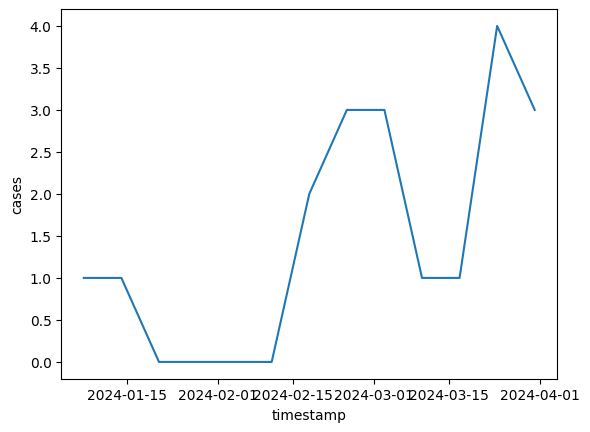

In [87]:
sns.lineplot(df[df['kz_kreis'] == '01002'], x = 'timestamp', y = 'cases')

In [3]:
"""
Synthetic epidemic dataset for testing spatial GNN advantage.
Load your real shapefile, simulate spatially-propagating cases, verify the signal, save as CSV.
"""

import numpy as np
import pandas as pd
import geopandas as gpd
from collections import defaultdict
from dataclasses import dataclass


@dataclass
class SyntheticEpiConfig:
    n_timesteps:        int   = 300
    spatial_lag:        int   = 2
    self_persistence:   float = 0.10
    neighbor_weight:    float = 0.65
    noise_std:          float = 0.05
    n_outbreaks:        int   = 10
    base_cases:         int   = 50
    outbreak_peak:      int   = 800
    seed:               int   = 42
    start_date:         str   = "2011-01-03"


def build_adjacency(gdf: gpd.GeoDataFrame, key_col: str) -> dict:
    touches   = gpd.sjoin(gdf[[key_col, 'geometry']], gdf[[key_col, 'geometry']], how='inner', predicate='touches')
    neighbors = defaultdict(list)
    for _, row in touches.iterrows():
        src, dst = str(row[f"{key_col}_left"]), str(row[f"{key_col}_right"])
        if src != dst:
            neighbors[src].append(dst)
    for k in gdf[key_col].astype(str):
        if k not in neighbors:
            neighbors[k] = []
    return dict(neighbors)


def simulate(nuts3_keys: list, adjacency: dict, cfg: SyntheticEpiConfig) -> np.ndarray:
    rng     = np.random.default_rng(cfg.seed)
    n       = len(nuts3_keys)
    idx_map = {k: i for i, k in enumerate(nuts3_keys)}
    cases   = np.zeros((cfg.n_timesteps, n), dtype=np.float64)

    outbreak_keys  = rng.choice(nuts3_keys, size=cfg.n_outbreaks, replace=False)
    outbreak_times = rng.integers(5, cfg.n_timesteps // 2, size=cfg.n_outbreaks)

    for t_seed, key in zip(outbreak_times, outbreak_keys):
        node_i = idx_map[key]
        for t in range(t_seed, min(t_seed + 10, cfg.n_timesteps)):
            cases[t, node_i] += cfg.outbreak_peak * np.exp(-0.4 * (t - t_seed))

    for t in range(cfg.spatial_lag, cfg.n_timesteps):
        for key, node_i in idx_map.items():
            nbrs           = adjacency.get(key, [])
            neighbor_signal = np.mean([cases[t - cfg.spatial_lag, idx_map[nbr]] for nbr in nbrs]) if nbrs else 0.0
            self_signal     = cases[t - 1, node_i]
            propagated      = (cfg.neighbor_weight * neighbor_signal
                               + cfg.self_persistence * self_signal
                               + cfg.base_cases
                               + rng.normal(0, cfg.noise_std * cfg.outbreak_peak))
            cases[t, node_i] += max(0.0, propagated)

    return np.round(cases).astype(int)


def verify_spatial_signal(cases: np.ndarray, nuts3_keys: list, adjacency: dict, lag: int):
    idx_map   = {k: i for i, k in enumerate(nuts3_keys)}
    corr_self, corr_nbr = [], []

    for key, node_i in idx_map.items():
        nbrs = adjacency.get(key, [])
        if not nbrs:
            continue
        target   = cases[lag:,  node_i].astype(float)
        self_lag = cases[:-lag, node_i].astype(float)
        nbr_lag  = np.mean([cases[:-lag, idx_map[nbr]] for nbr in nbrs], axis=0).astype(float)
        corr_self.append(np.corrcoef(self_lag, target)[0, 1])
        corr_nbr.append( np.corrcoef(nbr_lag,  target)[0, 1])

    mean_self    = np.nanmean(corr_self)
    mean_nbr     = np.nanmean(corr_nbr)
    pct_nbr_wins = np.mean(np.array(corr_nbr) > np.array(corr_self))

    print("=== Spatial Signal Verification ===")
    print(f"  Mean corr(self_lag → target):      {mean_self:.3f}")
    print(f"  Mean corr(neighbor_lag → target):  {mean_nbr:.3f}")
    print(f"  Neighbor signal stronger in:       {pct_nbr_wins:.0%} of nodes")
    if mean_nbr > mean_self + 0.10:
        print("  ✓ Spatial signal dominant — GNN should outperform identity.")
    else:
        print("  ✗ Spatial signal weak — increase neighbor_weight or reduce self_persistence.")


def build_dataframe(cases: np.ndarray, nuts3_keys: list, cfg: SyntheticEpiConfig) -> pd.DataFrame:
    timestamps = pd.date_range(start=cfg.start_date, periods=cfg.n_timesteps, freq="W-MON")
    index      = pd.MultiIndex.from_product([range(cfg.n_timesteps), nuts3_keys], names=["t_idx", "nuts3_key"])
    df         = pd.DataFrame({"cases": cases.flatten(order="C")}, index=index).reset_index()
    df["timestamp"] = df["t_idx"].map(lambda i: timestamps[i])
    df["year"]      = df["timestamp"].dt.year
    df["week"]      = df["timestamp"].dt.isocalendar().week.astype(int)
    return df[["week", "nuts3_key", "cases", "year", "timestamp"]]


# ── RUN ──────────────────────────────────────────────────────────────────────

In [ ]:

import os 
from src.utils import get_data_env

shapefile_path = os.path.join(get_data_env(), f'processed/germany/geospatial/shapefiles/shape_nuts3.shp')  # ← change this
output_path    = "synthetic_disease.csv"      # ← change this
key_col        = "nuts3_key"                  # ← adjust if your shapefile uses a different column name

cfg = SyntheticEpiConfig(
    n_timesteps     = 300,
    spatial_lag     = 2,
    self_persistence= 0.10,
    neighbor_weight = 0.65,
    n_outbreaks     = 10,
    seed            = 42,
)

gdf        = gpd.read_file(shapefile_path)
gdf         = gdf[gdf['nuts3_key'] != '11000']
nuts3_keys = sorted(gdf[key_col].astype(str).unique().tolist())
print(f"Loaded shapefile: {len(nuts3_keys)} regions")

adjacency  = build_adjacency(gdf, key_col)
print(f"Adjacency built: {sum(1 for v in adjacency.values() if v)}/{len(nuts3_keys)} nodes have neighbors")

cases      = simulate(nuts3_keys, adjacency, cfg)
print(f"Simulation done. Cases range: [{cases.min()}, {cases.max()}]")

verify_spatial_signal(cases, nuts3_keys, adjacency, cfg.spatial_lag)

df = build_dataframe(cases, nuts3_keys, cfg)
# df.to_csv(output_path, index=False)
print(f"\nSaved → {output_path}")
df.head()

Loaded shapefile: 412 regions
Adjacency built: 412/412 nodes have neighbors
Simulation done. Cases range: [0, 1087]
=== Spatial Signal Verification ===
  Mean corr(self_lag → target):      0.221
  Mean corr(neighbor_lag → target):  0.496
  Neighbor signal stronger in:       98% of nodes
  ✓ Spatial signal dominant — GNN should outperform identity.

Saved → synthetic_disease.csv


,week,nuts3_key,cases,year,timestamp
0,1,01001,0,2011,2011-01-03
1,1,01002,0,2011,2011-01-03
2,1,01003,0,2011,2011-01-03
3,1,01004,0,2011,2011-01-03
4,1,01051,0,2011,2011-01-03
